In [1]:
import numpy as np
from model_ranking import get_summary_results, results_to_arrays

In [ ]:
source_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito"]
### Only a single perturbation strength should be specified here at any one time
selected_augmentations = {
    "none": [""],
    #"DO": ["a0005", "a001", "a005", "a01", "a02", "a03", "a04", "a05"],
    "DO": ["a01"]
}
source_models={
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
per_target_norms = {
    "EPFL": ["Normalize"],
    "Hmito": ["Normalize"],
    "Rmito": ["Normalize"],
    "VNC": ["Normalize"],
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_keys2 = {
    "EPFL": "EI_th05",
    "Hmito": "EI_th05",
    "Rmito": "EI_th05",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
consis_postfix="median"
perf_postfix="median"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

In [ ]:
transfer_performance = np.zeros((len(source_datasets), len(targets)))
for target in targets:
    if target == "VNC":
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders={"VNC": "resized"},
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            base_seg_dir=base_result_path,
        )
    else:
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys2,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median_per_alpha",
            perf_postfix="median",
            base_seg_dir=base_result_path,
        )
        consis_str_VNC, _, NA_per_VNC = get_summary_results(
            source_data=["VNC"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            base_seg_dir=base_result_path,
        )
        consis_str.update(consis_str_VNC)
        NA_perf.update(NA_per_VNC)

    consis_scores, NA_perf_scores = results_to_arrays(
        consis_str, NA_perf, "DO", len(selected_augmentations["DO"])
    )
    if target == "VNC":
        NA_perf_scores = np.append(NA_perf_scores, np.nan)
    transfer_performance[:, targets.index(target)] = NA_perf_scores

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 18.03it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 19.56it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 25.05it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 22.26it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 24.41it/s]


In [ ]:
transfer_performance

array([[0.94850278, 0.37838694, 0.24683729, 0.38110751],
       [0.87699091, 0.95249295, 0.88592064, 0.64119923],
       [0.69233453, 0.84691751, 0.96010637, 0.17055579],
       [0.71236527, 0.45050278, 0.27781898,        nan]])

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

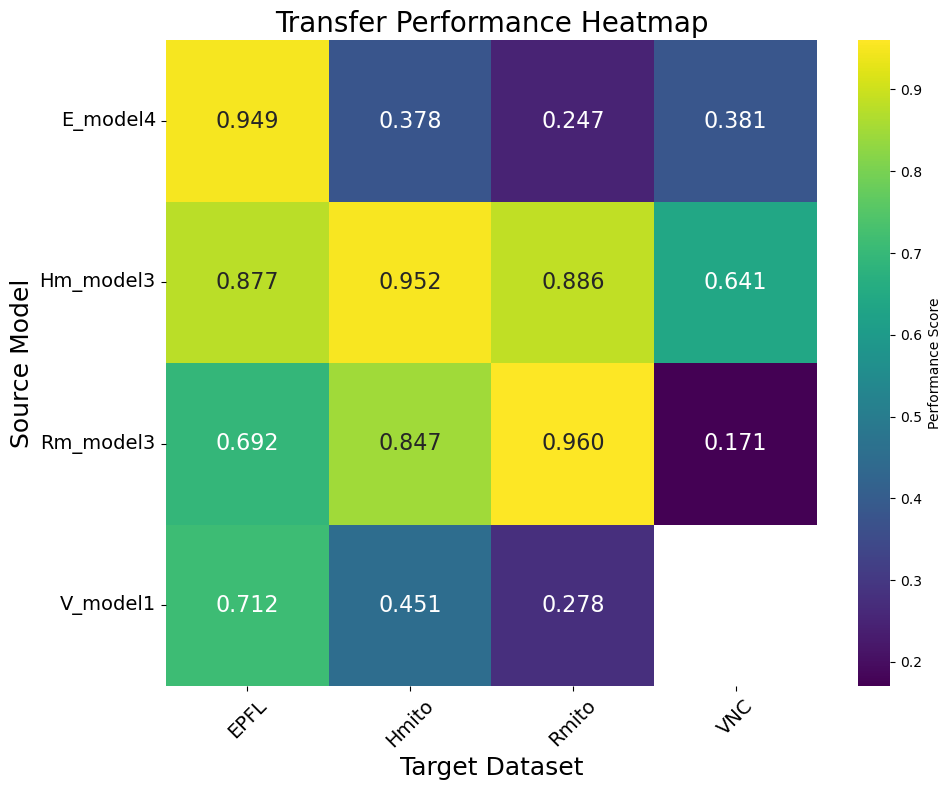

In [8]:
from numpy.typing import NDArray
from typing import Any, List, Tuple

# Define labels for the heatmap
source_model_names = ["E_model4", "Hm_model3", "Rm_model3", "V_model1"]
target_dataset_names = ["EPFL", "Hmito", "Rmito", "VNC"]


def plot_transfer_performance_heatmap(
    data: NDArray[Any], 
    source_labels: List[str], 
    target_labels: List[str], 
    figsize: Tuple[int,int]=(10, 8), 
    cmap: str ='viridis',
    fontsize: int =20
):
    """
    Plots a heatmap for transfer performance.

    Parameters:
        data (np.ndarray): 2D array of performance scores.
        source_labels (list): Labels for the y-axis (source models).
        target_labels (list): Labels for the x-axis (target datasets).
        figsize (tuple): Figure size.
        cmap (str): Colormap for the heatmap.
    """
    _ = plt.figure(figsize=figsize)
    _ = sns.heatmap(
        data,
        xticklabels=target_labels,
        yticklabels=source_labels,
        annot=True,
        fmt='.3f',
        cmap=cmap,
        cbar_kws={'label': 'Performance Score'},
        annot_kws={'size': fontsize-4}
    )
    _ = plt.xlabel('Target Dataset', fontsize=fontsize-2)
    _ = plt.ylabel('Source Model', fontsize=fontsize-2)
    _ = plt.title('Transfer Performance Heatmap', fontsize=fontsize)
    _ = plt.tick_params(axis='both', which='major', labelsize=fontsize-6)
    _ = plt.xticks(rotation=45) # pyright: ignore[reportUnknownVariableType]
    _ = plt.yticks(rotation=0) # pyright: ignore[reportUnknownVariableType]
    plt.tight_layout()
    plt.show()

# Example usage:
plot_transfer_performance_heatmap(
    transfer_performanace,
    source_model_names,
    target_dataset_names
)

# Unetr Results

In [ ]:
source_datasets = ["EPFL", "Hmito", "Rmito"]
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["Rmito"]
### Only a single perturbation strength should be specified here at any one time
selected_augmentations = None
source_models={
    "EPFL": "E_model_Unetr1",
    "Hmito": "Hm_model_Unetr1",
    "Rmito": "Rm_model_Unetr1",
}
per_target_norms = {
    "EPFL": ["Normalize"],
    "Hmito": ["Normalize"],
    "Rmito": ["Normalize"],
    "VNC": ["Normalize"],
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_keys=None
perf_key = "hard_f1"
approach="feature_perturbation_consistency"
consis_postfix="median"
perf_postfix="median"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

In [20]:
from typing import Dict 
def perf_results_to_array(
    perf_scores: Dict[str, Dict[str, float]],
):
    perf_array = np.zeros(len(perf_scores))
    for i, (_, per_norm_perf) in enumerate(perf_scores.items()):
        norm = list(per_norm_perf.keys())[0]
        perf_array[i] = per_norm_perf[norm]
    return perf_array

In [26]:
list(source_models.values())

['E_model_Unetr1', 'Hm_model_Unetr1', 'Rm_model_Unetr1']

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 179.81it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 185.45it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 227.57it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 212.39it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 197.00it/s]


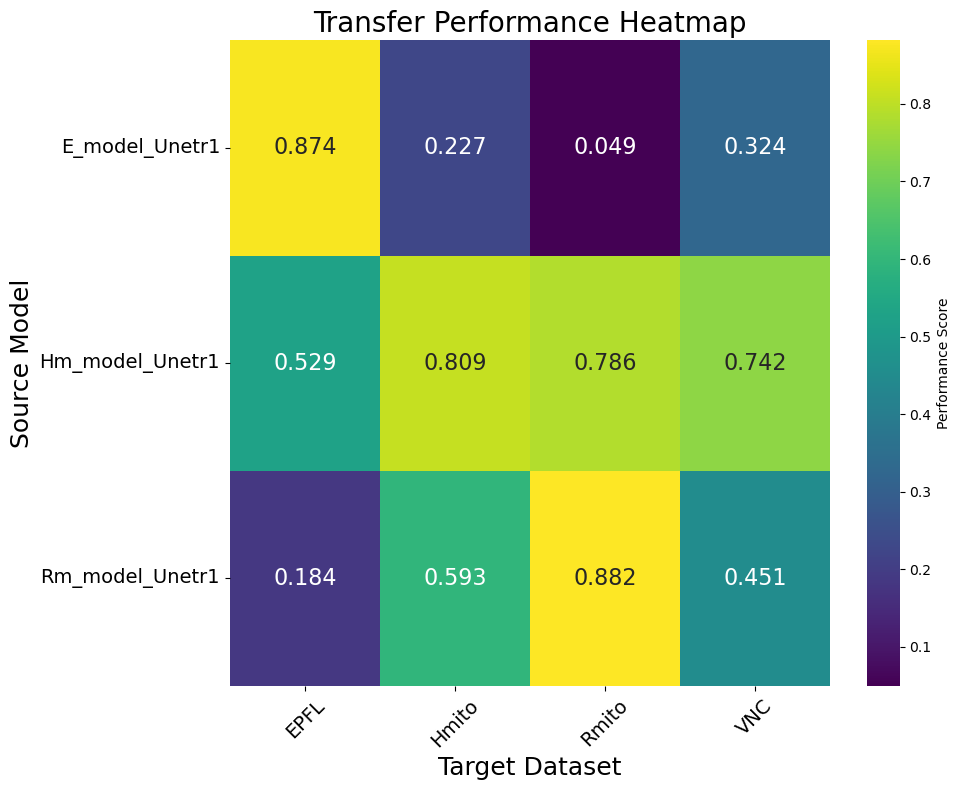

In [27]:
transfer_performance = np.zeros((len(source_datasets), len(targets)))
for target in targets:
    _, _, NA_perf = get_summary_results(
        source_data=["EPFL", "Hmito", "Rmito"],
        target_data=[target],
        source_models=source_models,
        selected_augmentations=None,
        selected_norms=per_target_norms,
        consis_keys=None,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        base_seg_dir=base_result_path,
    )
    NA_perf_scores = perf_results_to_array(NA_perf)
    transfer_performance[:, targets.index(target)] = NA_perf_scores

plot_transfer_performance_heatmap(
    transfer_performance,
    list(source_models.values()),
    targets
)

In [24]:
transfer_performanace

array([[0.87428951, 0.22659691, 0.04928457, 0.32418609],
       [0.52903569, 0.80937552, 0.78621536, 0.74180984],
       [0.18422759, 0.59307504, 0.88207424, 0.45069373]])

In [17]:
NA_perf

{'E_to_V': {'norm_Normalize': 0.3241860866546631},
 'Hm_to_V': {'norm_Normalize': 0.7418098449707031},
 'Rm_to_V': {'norm_Normalize': 0.4506937265396118}}

In [13]:
perf_array = perf_results_to_array(NA_perf)
print(perf_array)

[0.32418609 0.74180984 0.45069373]
